In [41]:
# Step 1 : Importing Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

In [42]:
# Step 2 : Load dataset
df = pd.read_csv("INDUSTRY.csv")
df

,id,company_name,industry,country,employee_count,annual_revenue_million,profit_margin_percent,founded_year,customer_count,market_rating,created_date,region
0,1,FinTrust_1,Finance,India,535,539.38,40.42,2010,81191,0.7,13-10-2025,Asia
1,2,TechNova_2,Technology,Germany,3806,852.42,39.55,2010,92162,3.4,01-12-2025,Europe
2,3,RetailHub_3,Retail,Canada,2779,257.11,23.68,1996,27532,2.9,04-05-2025,North America
3,4,BuildWorks_4,Manufacturing,USA,835,309.14,31.31,1993,90815,0.9,01-02-2026,North America
4,5,MediCorp_5,Healthcare,India,4490,988.68,43.65,1996,850,0.5,29-06-2025,Asia
...,...,...,...,...,...,...,...,...,...,...,...,...
14995,14996,FinTrust_14996,Finance,USA,2814,369.06,25.59,2011,52295,1.6,25-08-2024,North America
14996,14997,TechNova_14997,Technology,India,3977,758.47,32.68,2019,4118,0.3,30-04-2024,Asia
14997,14998,RetailHub_14998,Retail,Germany,454,859.89,15.36,1999,54468,0.1,05-04-2024,Europe
14998,14999,BuildWorks_14999,Manufacturing,Canada,2787,111.92,41.82,2019,74866,1.9,30-12-2024,North America


In [43]:
# Step 3 : Read dataset and understand data structure
df.head()

,id,company_name,industry,country,employee_count,annual_revenue_million,profit_margin_percent,founded_year,customer_count,market_rating,created_date,region
0,1,FinTrust_1,Finance,India,535,539.38,40.42,2010,81191,0.7,13-10-2025,Asia
1,2,TechNova_2,Technology,Germany,3806,852.42,39.55,2010,92162,3.4,01-12-2025,Europe
2,3,RetailHub_3,Retail,Canada,2779,257.11,23.68,1996,27532,2.9,04-05-2025,North America
3,4,BuildWorks_4,Manufacturing,USA,835,309.14,31.31,1993,90815,0.9,01-02-2026,North America
4,5,MediCorp_5,Healthcare,India,4490,988.68,43.65,1996,850,0.5,29-06-2025,Asia


In [44]:
df.tail()

,id,company_name,industry,country,employee_count,annual_revenue_million,profit_margin_percent,founded_year,customer_count,market_rating,created_date,region
14995,14996,FinTrust_14996,Finance,USA,2814,369.06,25.59,2011,52295,1.6,25-08-2024,North America
14996,14997,TechNova_14997,Technology,India,3977,758.47,32.68,2019,4118,0.3,30-04-2024,Asia
14997,14998,RetailHub_14998,Retail,Germany,454,859.89,15.36,1999,54468,0.1,05-04-2024,Europe
14998,14999,BuildWorks_14999,Manufacturing,Canada,2787,111.92,41.82,2019,74866,1.9,30-12-2024,North America
14999,15000,MediCorp_15000,Healthcare,USA,1473,879.67,29.31,2003,12998,2.0,14-03-2024,North America


In [45]:
df.shape   # to know number of rows and columns

(15000, 12)

In [46]:
df.columns   # to know column names

Index(['id', 'company_name', 'industry', 'country', 'employee_count',
       'annual_revenue_million', 'profit_margin_percent', 'founded_year',
       'customer_count', 'market_rating', 'created_date', 'region'],
      dtype='object')

In [47]:
df.dtypes  # to know data types of columns

id                          int64
company_name               object
industry                   object
country                    object
employee_count              int64
annual_revenue_million    float64
profit_margin_percent     float64
founded_year                int64
customer_count              int64
market_rating             float64
created_date               object
region                     object
dtype: object

In [48]:
df.info() # to know more about data types and non-null values in each column

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      15000 non-null  int64  
 1   company_name            15000 non-null  object 
 2   industry                15000 non-null  object 
 3   country                 15000 non-null  object 
 4   employee_count          15000 non-null  int64  
 5   annual_revenue_million  15000 non-null  float64
 6   profit_margin_percent   15000 non-null  float64
 7   founded_year            15000 non-null  int64  
 8   customer_count          15000 non-null  int64  
 9   market_rating           15000 non-null  float64
 10  created_date            15000 non-null  object 
 11  region                  15000 non-null  object 
dtypes: float64(3), int64(4), object(5)
memory usage: 1.4+ MB


In [49]:
# Step 4 : cleaning data and handling missing values
# convert created_date -> object to datetime
df['created_date'] = pd.to_datetime(df['created_date'])

C:\Users\91702\AppData\Local\Temp\ipykernel_26996\245543974.py:3: UserWarning: Parsing dates in DD/MM/YYYY format when dayfirst=False (the default) was specified. This may lead to inconsistently parsed dates! Specify a format to ensure consistent parsing.
  df['created_date'] = pd.to_datetime(df['created_date'])


In [50]:
df.dtypes  # to recheck data type of created_date column after conversion

id                                 int64
company_name                      object
industry                          object
country                           object
employee_count                     int64
annual_revenue_million           float64
profit_margin_percent            float64
founded_year                       int64
customer_count                     int64
market_rating                    float64
created_date              datetime64[ns]
region                            object
dtype: object

In [51]:
df.isnull().sum()  # to check for missing values in each column

id                        0
company_name              0
industry                  0
country                   0
employee_count            0
annual_revenue_million    0
profit_margin_percent     0
founded_year              0
customer_count            0
market_rating             0
created_date              0
region                    0
dtype: int64

#Analysis : All columns have 0 missing values means dataset contains no missing data,
#so we can proceed with EDA without worrying about missing data imputation.


In [52]:
# Duplicate Checks
df.duplicated().sum() # to check for duplicate rows in the dataset


0

 #returned 0, which means there are no fully duplicate rows in the dataset. In other words, every row is unique across all columns.

In [53]:
# Step 5 : Exploratory Data Analysis (EDA)
# Summary statistics
df.describe() 

,id,employee_count,annual_revenue_million,profit_margin_percent,founded_year,customer_count,market_rating
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,7500.500000,2606.862067,549.732707,25.012019,2004.374000,50449.251867,2.513780
std,4330.271354,1430.562513,288.244128,11.526187,8.606687,28744.638830,1.447998
min,1.000000,100.000000,50.160000,5.000000,1990.000000,500.000000,0.000000
25%,3750.750000,1379.000000,299.915000,15.050000,1997.000000,25676.250000,1.200000
50%,7500.500000,2587.000000,543.920000,24.910000,2004.000000,50726.500000,2.500000
75%,11250.250000,3839.000000,797.570000,35.100000,2012.000000,75271.250000,3.800000
max,15000.000000,5099.000000,1049.960000,45.000000,2019.000000,100495.000000,5.000000


In [54]:
# Seperate numerical and categorical columns 
df.select_dtypes(include=np.number).columns

Index(['id', 'employee_count', 'annual_revenue_million',
       'profit_margin_percent', 'founded_year', 'customer_count',
       'market_rating'],
      dtype='object')

In [55]:
df.select_dtypes(include='object').columns

Index(['company_name', 'industry', 'country', 'region'], dtype='object')

In [56]:
df.select_dtypes(include='datetime').columns

Index(['created_date'], dtype='object')

#Step 6 : Univariate Analysis
#Numerical columns - Histogram , Box plot , distribution, skewness, kurtosis

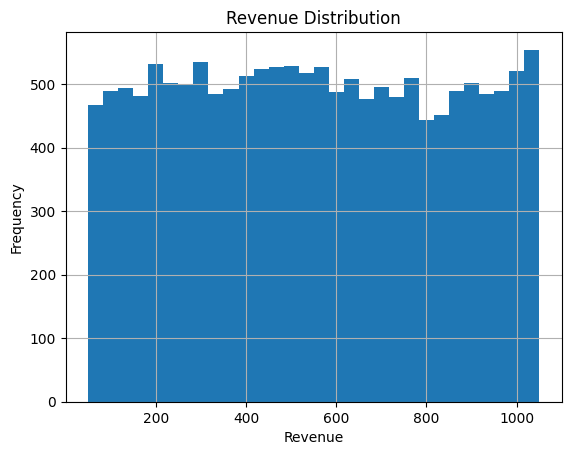

In [57]:
# Histogram for numerical columns
df['annual_revenue_million'].hist(bins=30)
plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.show()

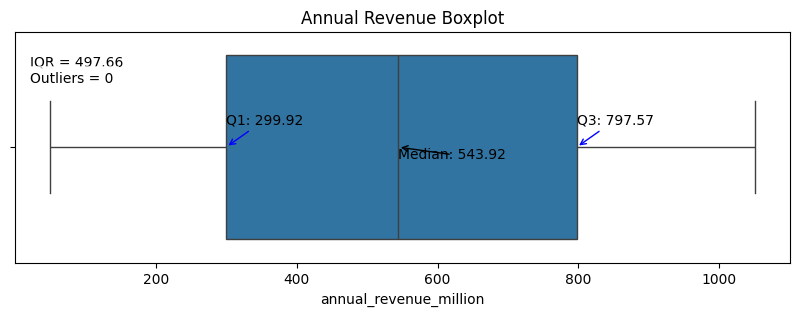

In [58]:
# Boxplot with median, spread, and outlier annotations
rev = df['annual_revenue_million']
q1 = rev.quantile(0.25)
q3 = rev.quantile(0.75)
median = rev.median()
iqr = q3 - q1
lower_whisker = q1 - 1.5 * iqr
upper_whisker = q3 + 1.5 * iqr
outliers = rev[(rev < lower_whisker) | (rev > upper_whisker)]
fig, ax = plt.subplots(figsize=(10, 3))
sns.boxplot(x=rev, ax=ax)
ax.set_title('Annual Revenue Boxplot')
ax.set_xlabel('annual_revenue_million')
ax.annotate(f'Median: {median:.2f}', xy=(median, 0), xytext=(median, 0.45), textcoords=('data', 'axes fraction'), arrowprops=dict(arrowstyle='->', color='black'))
ax.annotate(f'Q1: {q1:.2f}', xy=(q1, 0), xytext=(q1, 0.60), textcoords=('data', 'axes fraction'), arrowprops=dict(arrowstyle='->', color='blue'))
ax.annotate(f'Q3: {q3:.2f}', xy=(q3, 0), xytext=(q3, 0.60), textcoords=('data', 'axes fraction'), arrowprops=dict(arrowstyle='->', color='blue'))
ax.text(0.02, 0.85, f'IQR = {iqr:.2f}', transform=ax.transAxes, fontsize=10, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
ax.text(0.02, 0.78, f'Outliers = {len(outliers)}', transform=ax.transAxes, fontsize=10, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
for i, val in enumerate(outliers.head(5)):
    ax.text(val, 0.15 - i * 0.08, f'{val:.0f}', ha='center', va='center', color='red')
plt.show()

Analysis : The boxplot is analyzing the distribution of annual_revenue_million:
The central box shows the interquartile range (IQR) from Q1 = 299.92 to Q3 = 797.57.
The line inside the box is the median, about 543.92, so half of the companies have revenue below that and half above.
The whiskers extend to the “normal” range defined by 1.5×IQR; here that is from about -446.57 to 1544.05.
Since revenue cannot be negative, the lower whisker is effectively at the minimum observed value.
There are 0 outliers by the 1.5×IQR rule, so the revenue values are fairly well contained within the expected range.
In short: the annual revenues are moderately skewed upward, with the middle 50% roughly between 300 and 798 million and no extreme outlier values detected.

In [59]:
# Skewness and Kurtosis
skew(df['annual_revenue_million'])


0.027338494990466998

In [60]:
kurtosis(df['annual_revenue_million'])

-1.1870634023152407

Skewness and Kurtosis Interpretation

skewness ≈ 0.0273
This is very close to zero, so the annual_revenue_million distribution is almost symmetric.
A small positive value means a tiny right skew, but not enough to call the data strongly skewed.

kurtosis ≈ -1.1871
This is negative, so the distribution is platykurtic.
It means the revenue values have lighter tails and fewer extreme extremes than a normal distribution.

What it indicates : 
The revenue distribution is near-normal in shape, not strongly skewed.
There are relatively few extreme outliers compared to a normal distribution.
Combined with the boxplot result of 0 outliers, the data is fairly well behaved and not heavy-tailed.


In [61]:
# Mean / Median / Mode
print('mean:', df['annual_revenue_million'].mean())
print('median:', df['annual_revenue_million'].median())
print('mode:', df['annual_revenue_million'].mode())

mean: 549.7327066666667
median: 543.9200000000001
mode: 0    265.24
Name: annual_revenue_million, dtype: float64


Analysis:

Although the mean is slightly higher than the median and mode, the skewness value (~0.027) is very close to zero.

Therefore, the annual_revenue_million distribution can be considered approximately symmetric with very little skewness.

This indicates that revenue values are relatively balanced around the center and there are no extreme distortions in the distribution.

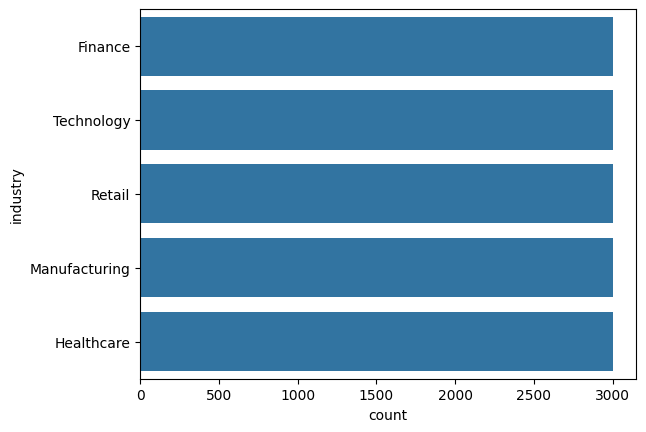

In [62]:
# Step 7 : Categorical Analysis
sns.countplot(y=df['industry'])
plt.show()

IQR Method

Formula 
IQR = Q3 - Q1

Outliers boundaries

Lower bound = Q1 - 1.5(IQR)

Upper bound = Q3 + 1.5(IQR)

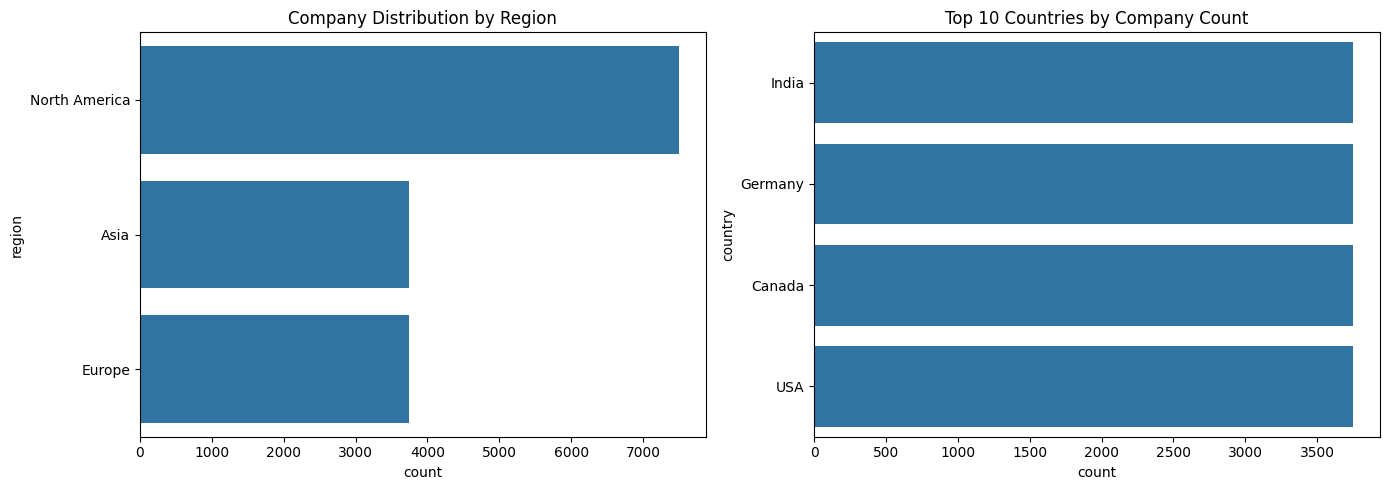

Industry Distribution


Finance          3000
Technology       3000
Retail           3000
Manufacturing    3000
Healthcare       3000
Name: industry, dtype: int64


Region Distribution


North America    7500
Asia             3750
Europe           3750
Name: region, dtype: int64

In [78]:
# Additional Categorical Analysis

fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.countplot(y='region', data=df,
              order=df['region'].value_counts().index,
              ax=axes[0])

axes[0].set_title('Company Distribution by Region')

sns.countplot(y='country', data=df,
              order=df['country'].value_counts().head(10).index,
              ax=axes[1])

axes[1].set_title('Top 10 Countries by Company Count')

plt.tight_layout()
plt.show()

print("Industry Distribution")
display(df['industry'].value_counts())

print("\nRegion Distribution")
display(df['region'].value_counts())

Analysis:

The company distribution analysis helps identify which industries, regions, and countries have the highest concentration of companies.

This provides insights into market presence and geographical business distribution patterns.

In [63]:
Q1 = df['annual_revenue_million'].quantile(0.25)
Q3 = df['annual_revenue_million'].quantile(0.75)
IQR = Q3-Q1
lower_bound = Q1-1.5*IQR
upper_bound = Q3+1.5*IQR
outliers = df[(df['annual_revenue_million'] < lower_bound) | (df['annual_revenue_million'] > upper_bound)]
print(outliers.shape)

(0, 12)


(0, 12) means:

0 rows matched the outlier condition

12 columns are in the dataset

So the analysis is:

There are no records in df whose annual_revenue_million is below Q1 - 1.5*IQR or above Q3 + 1.5*IQR
In other words, annual_revenue_million has 0 outliers by the standard IQR rule
This confirms the revenue values are fairly contained within the expected range and not extreme compared to the rest of the data

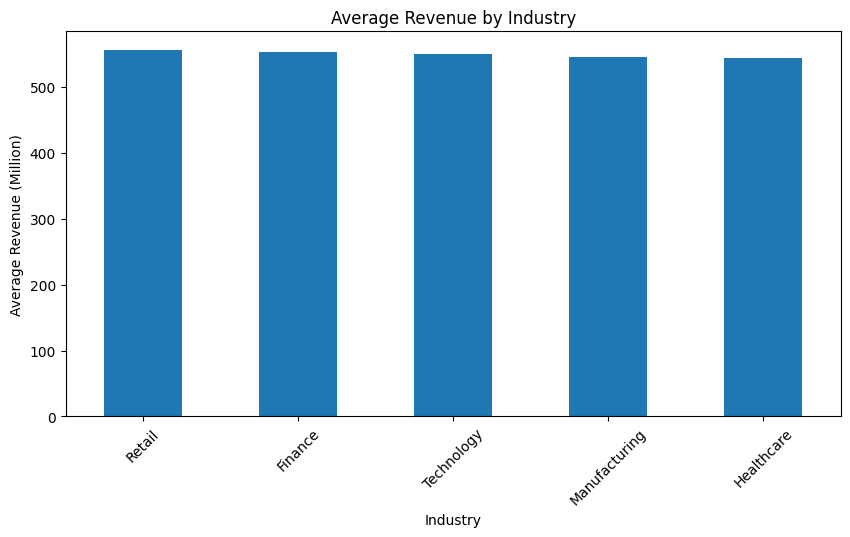

industry
Retail           556.609343
Finance          552.823690
Technology       550.198027
Manufacturing    545.575197
Healthcare       543.457277
Name: annual_revenue_million, dtype: float64

In [79]:
# Top Industries by Average Revenue

industry_revenue = (
    df.groupby('industry')['annual_revenue_million']
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))
industry_revenue.plot(kind='bar')

plt.title('Average Revenue by Industry')
plt.ylabel('Average Revenue (Million)')
plt.xlabel('Industry')
plt.xticks(rotation=45)

plt.show()

industry_revenue

Analysis:

This analysis helps identify which industries generate the highest average revenue.

Industries with higher average revenue may indicate stronger market performance and greater business opportunities.

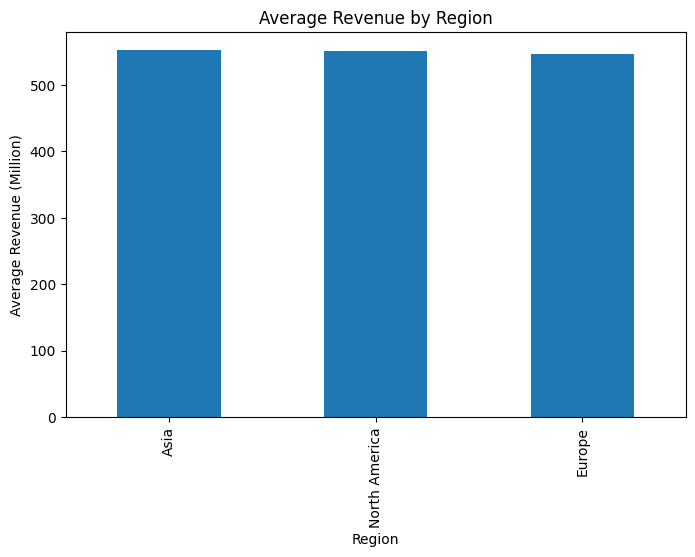

region
Asia             551.872211
North America    550.641687
Europe           545.775243
Name: annual_revenue_million, dtype: float64

In [80]:
# Region-wise Revenue Analysis

region_revenue = (
    df.groupby('region')['annual_revenue_million']
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
region_revenue.plot(kind='bar')

plt.title('Average Revenue by Region')
plt.ylabel('Average Revenue (Million)')
plt.xlabel('Region')

plt.show()

region_revenue

Analysis:

Comparing revenue across regions helps identify geographical areas that contribute the most to business performance.

Regions with higher revenue may represent stronger economic activity and market demand.

 Step 8 : BIVARIATE ANALYSIS

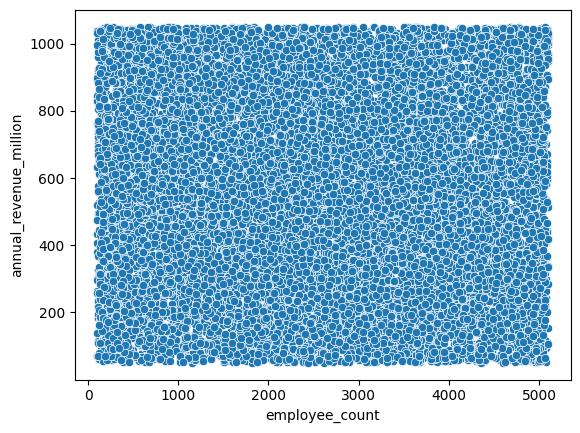

In [64]:
# Numerical vs Numerical
sns.scatterplot(
    x='employee_count',
    y='annual_revenue_million',
    data=df
)

plt.show()

In [65]:
#Correlation
df[['employee_count',
    'annual_revenue_million']].corr()  # to find correlation between employee_count and annual_revenue_million

,employee_count,annual_revenue_million
employee_count,1.000000,-0.002043
annual_revenue_million,-0.002043,1.000000


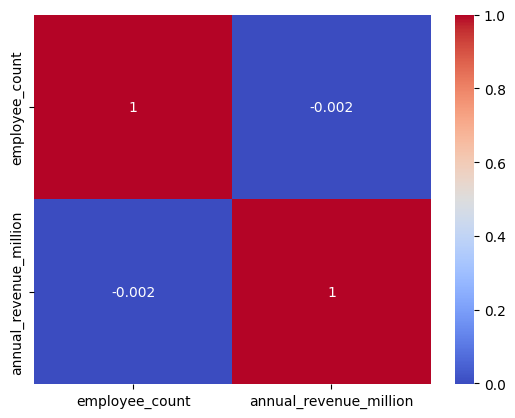

In [66]:
# Heat map for correlation
corr = df[['employee_count', 'annual_revenue_million']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

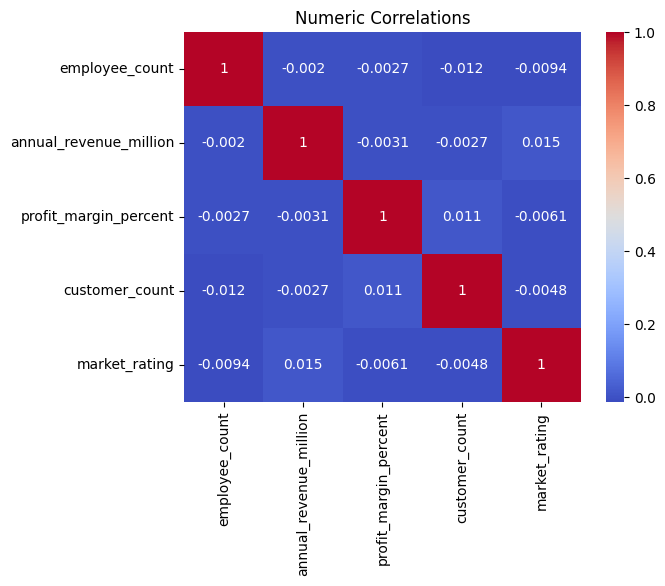

In [ ]:
# Strongest Correlations

corr_matrix = df[[
    'employee_count',
    'annual_revenue_million',
    'profit_margin_percent',
    'customer_count',
    'market_rating'
]]

numeric_cols = corr_matrix.columns.tolist()

# correlation heatmap
corr = corr_matrix.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Numeric Correlations')
plt.show()

# pairplot for numeric variables
sns.pairplot(df[numeric_cols], corner=True, kind='reg')
plt.show()

# pairplot colored by industry
sns.pairplot(df[numeric_cols + ['industry']], hue='industry', corner=True)
plt.show()

# group summary by industry
print(df.groupby('industry')[numeric_cols].mean())

corr_pairs = (
    corr_matrix
      .unstack()
      .sort_values(ascending=False)
)

corr_pairs = corr_pairs[
    corr_pairs < 1
]

corr_pairs.head(10)

C:\Users\91702\AppData\Local\Temp\ipykernel_26996\1780290925.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(order, rotation=45, ha='right')


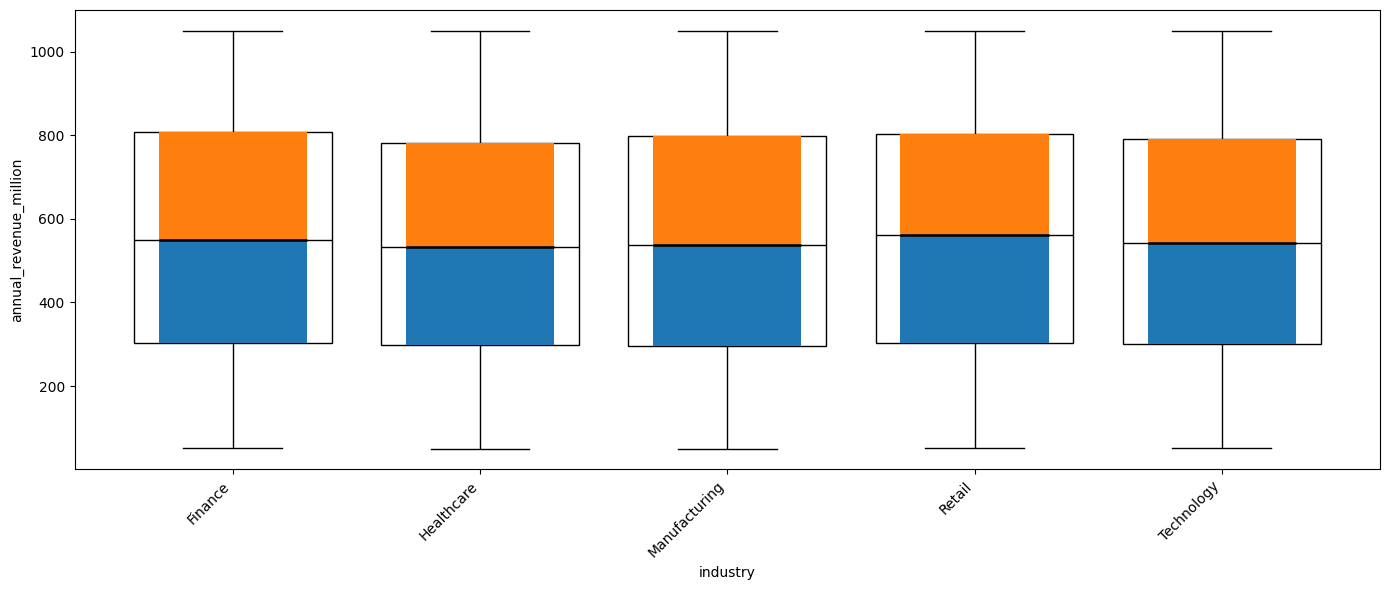

In [67]:
# Numerical vs Categorical
order = sorted(df['industry'].unique())
fig, ax = plt.subplots(figsize=(14,6))

# draw box outlines only (no fill)
sns.boxplot(x='industry', y='annual_revenue_million', data=df,
            order=order, ax=ax,
            boxprops=dict(facecolor='none', edgecolor='black'),
            whiskerprops=dict(color='black'),
            capprops=dict(color='black'),
            medianprops=dict(color='black'),
            flierprops=dict(markeredgecolor='gray'))

width = 0.6  # box width
lower_color = '#1f77b4'
upper_color = '#ff7f0e'

for i, ind in enumerate(order):
    grp = df.loc[df['industry'] == ind, 'annual_revenue_million']
    q1 = grp.quantile(0.25)
    q3 = grp.quantile(0.75)
    med = grp.median()
    x_left = i - width/2
    # lower half (Q1 -> median)
    if med > q1:
        ax.add_patch(plt.Rectangle((x_left, q1), width, med - q1,
                                   facecolor=lower_color, edgecolor='none', zorder=2))
    # upper half (median -> Q3)
    if q3 > med:
        ax.add_patch(plt.Rectangle((x_left, med), width, q3 - med,
                                   facecolor=upper_color, edgecolor='none', zorder=2))
    # redraw median line on top
    ax.hlines(med, i - width/2, i + width/2, color='black', linewidth=1.8, zorder=3)

ax.set_xticklabels(order, rotation=45, ha='right')
ax.set_xlabel('industry')
ax.set_ylabel('annual_revenue_million')
plt.tight_layout()
plt.show()

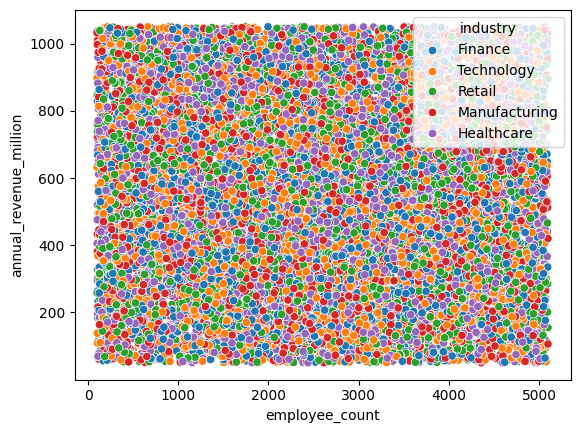

In [68]:
#MULTIVARIATE ANALYSIS
sns.scatterplot(
    x='employee_count',
    y='annual_revenue_million',
    hue='industry',
    data=df
)

plt.show()

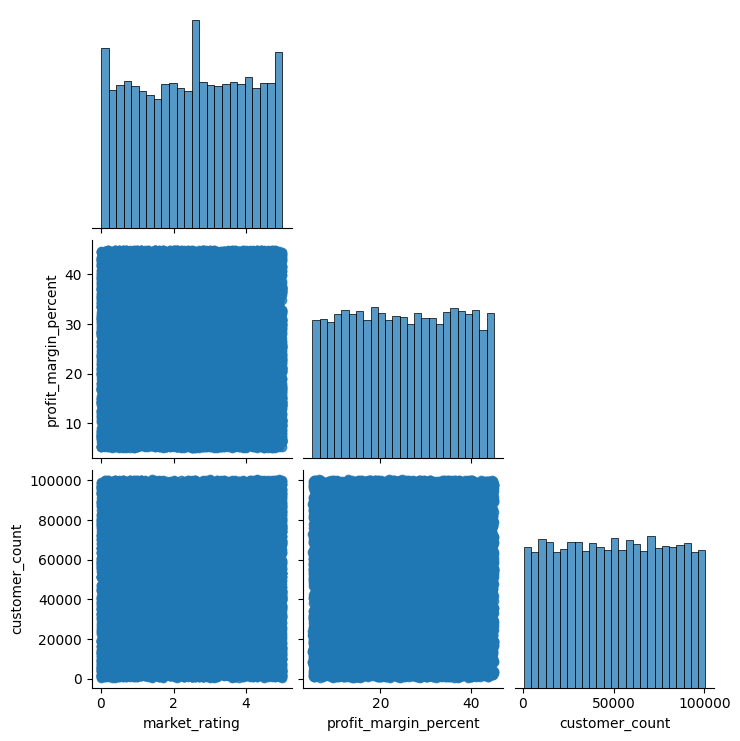

In [69]:
sns.pairplot(df[['market_rating', 'profit_margin_percent', 'customer_count']], corner=True, kind='reg')
plt.show()

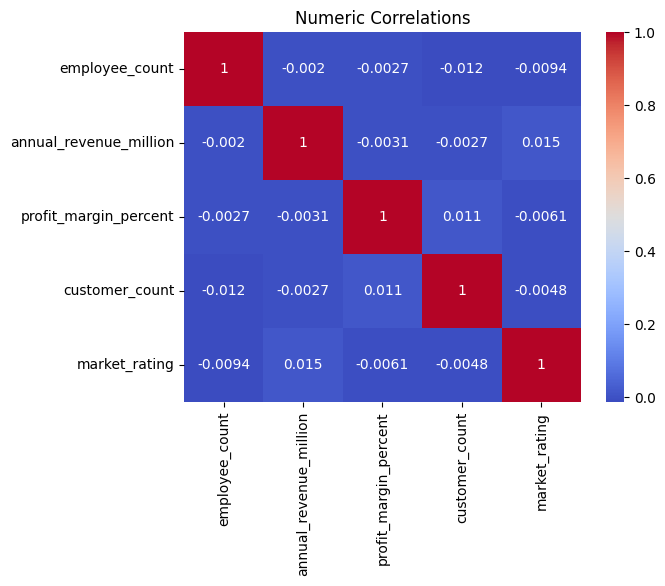

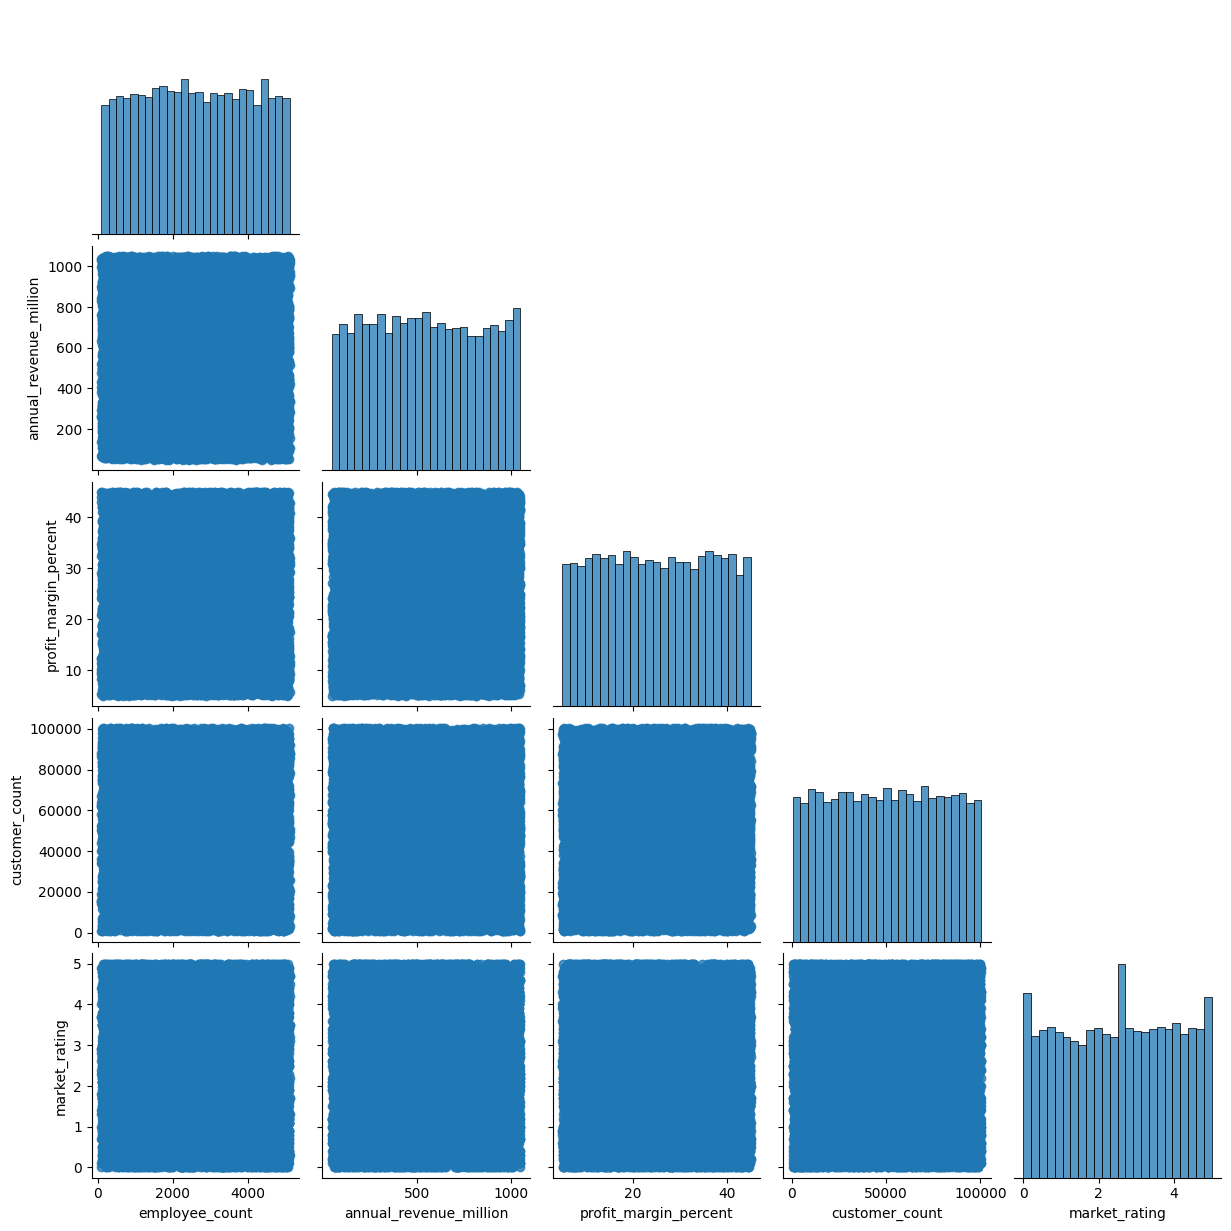

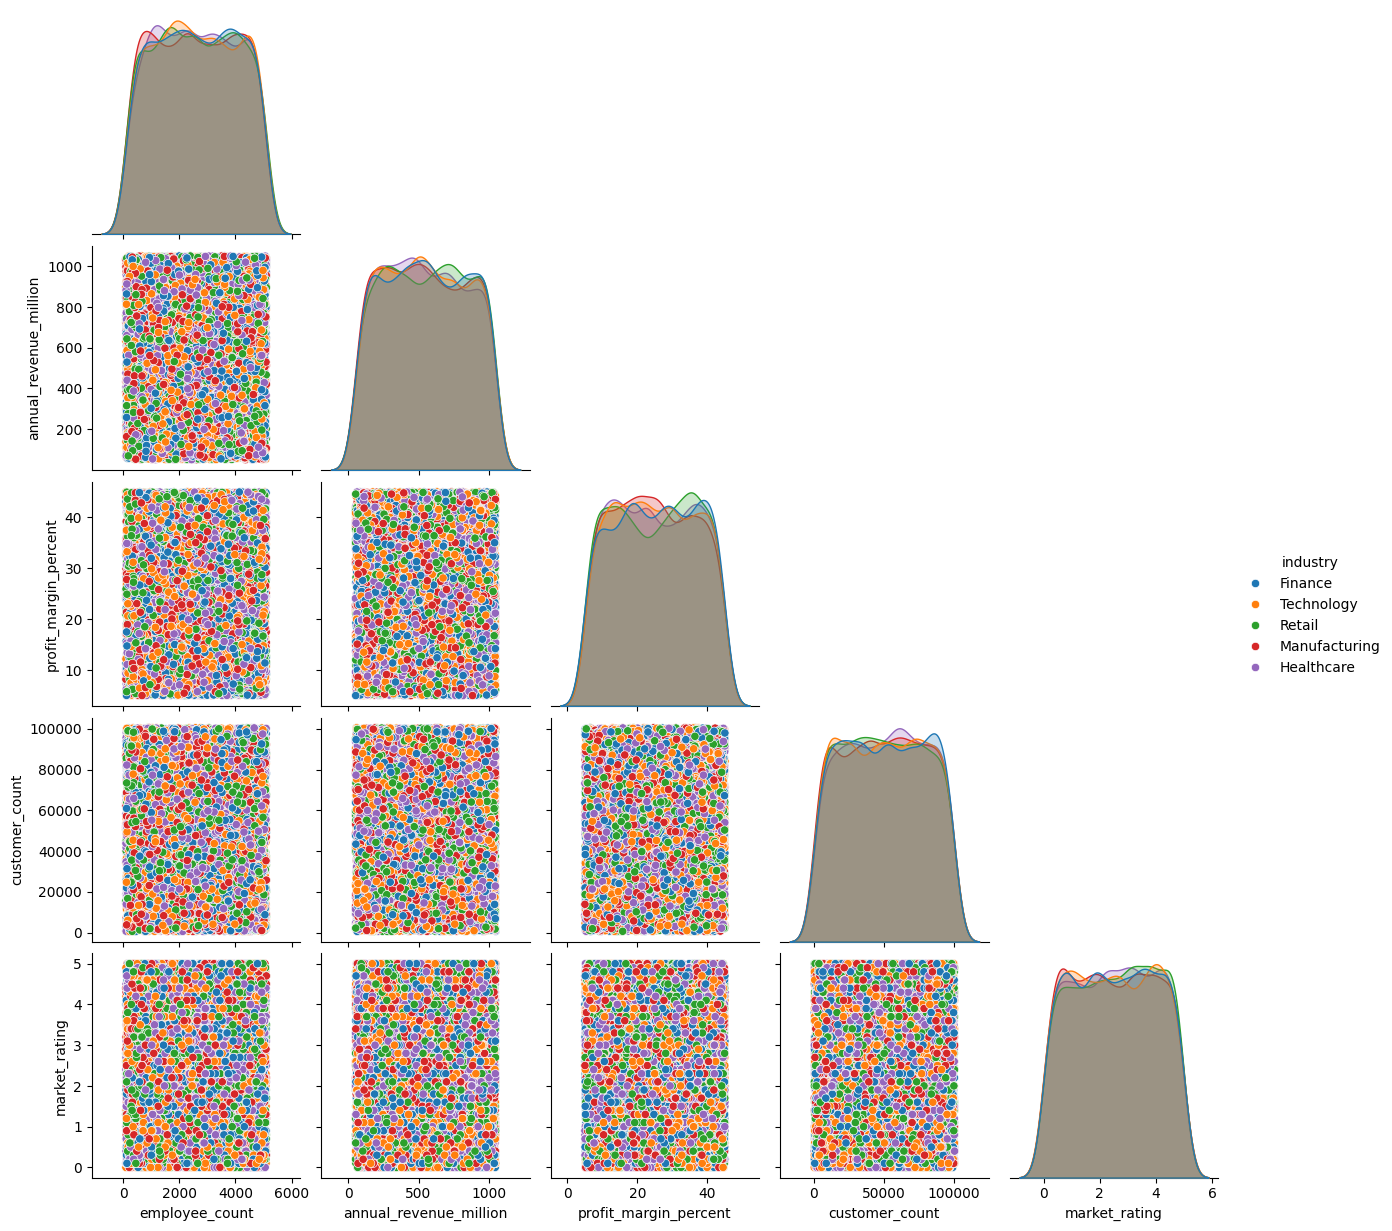

               employee_count  annual_revenue_million  profit_margin_percent  \
industry                                                                       
Finance           2621.878333              552.823690              25.303310   
Healthcare        2610.893667              543.457277              24.878077   
Manufacturing     2582.221000              545.575197              24.762147   
Retail            2608.425000              556.609343              25.085197   
Technology        2610.892333              550.198027              25.031367   

               customer_count  market_rating  
industry                                      
Finance          50665.919000       2.512100  
Healthcare       51025.384333       2.515967  
Manufacturing    50220.057333       2.491100  
Retail           49979.257333       2.554533  
Technology       50355.641333       2.495200  


In [70]:
numeric_cols = [
    'employee_count',
    'annual_revenue_million',
    'profit_margin_percent',
    'customer_count',
    'market_rating'
]

# correlation heatmap
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Numeric Correlations')
plt.show()

# pairplot for numeric variables
sns.pairplot(df[numeric_cols], corner=True, kind='reg')
plt.show()

# pairplot colored by industry
sns.pairplot(df[numeric_cols + ['industry']], hue='industry', corner=True)
plt.show()

# group summary by industry
print(df.groupby('industry')[numeric_cols].mean())

Numeric columns used for multivariate analysis:
['employee_count', 'annual_revenue_million', 'profit_margin_percent', 'customer_count', 'market_rating', 'company_age']

Correlation matrix:
                        employee_count  annual_revenue_million  \
employee_count                1.000000               -0.002043   
annual_revenue_million       -0.002043                1.000000   
profit_margin_percent        -0.002724               -0.003120   
customer_count               -0.012431               -0.002673   
market_rating                -0.009352                0.014639   
company_age                  -0.021180                0.011840   

                        profit_margin_percent  customer_count  market_rating  \
employee_count                      -0.002724       -0.012431      -0.009352   
annual_revenue_million              -0.003120       -0.002673       0.014639   
profit_margin_percent                1.000000        0.011347      -0.006096   
customer_count              

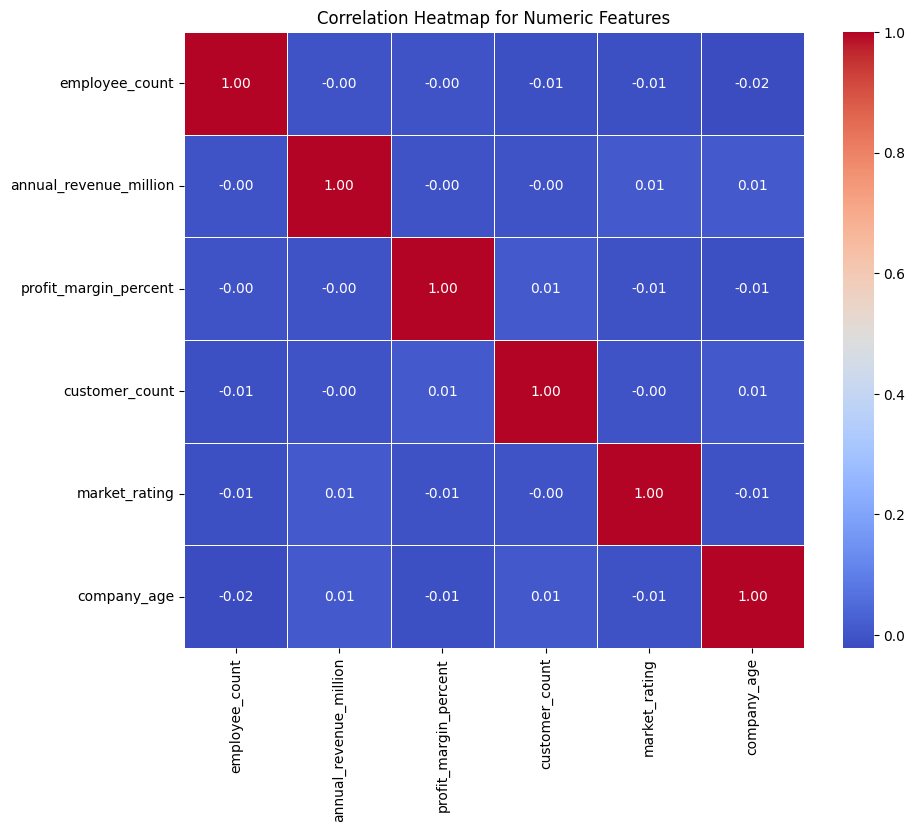

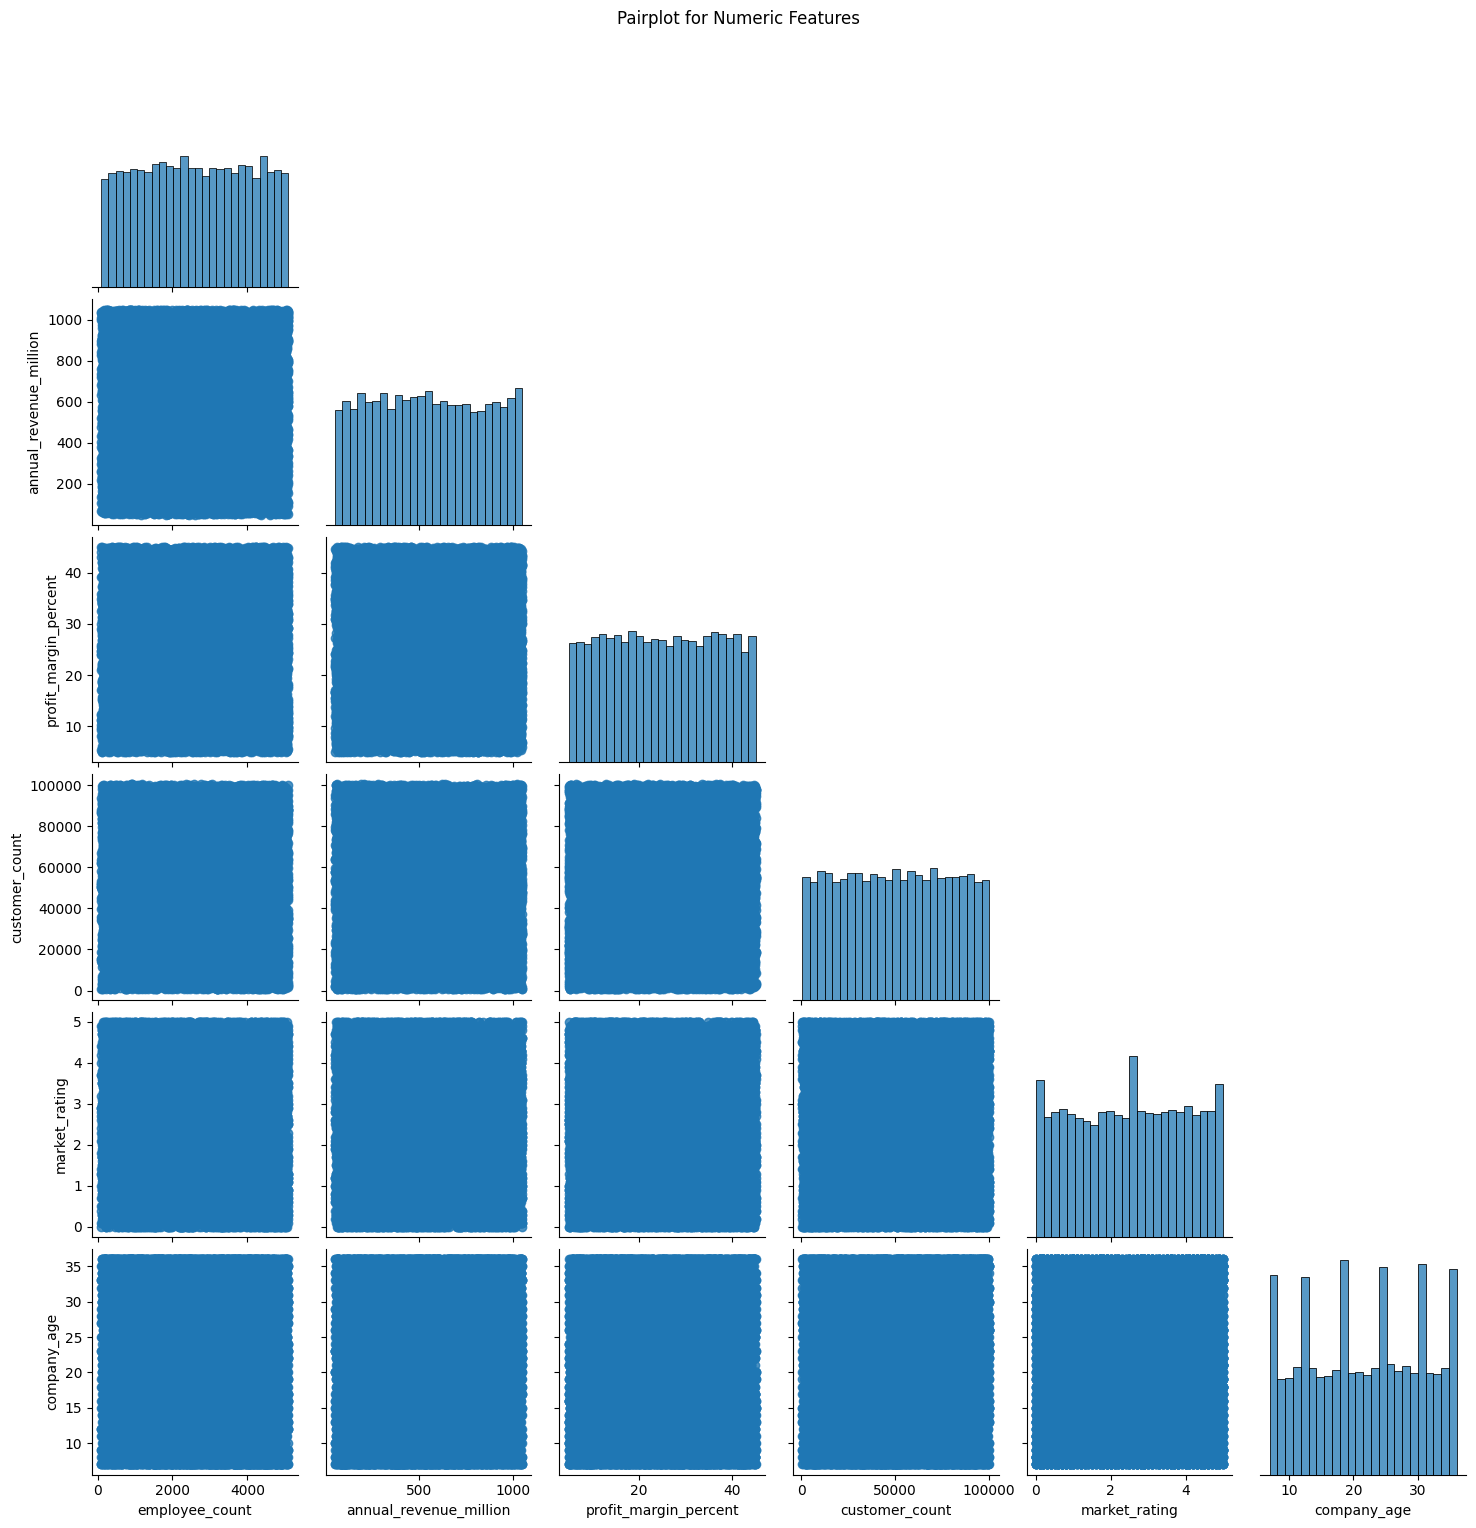

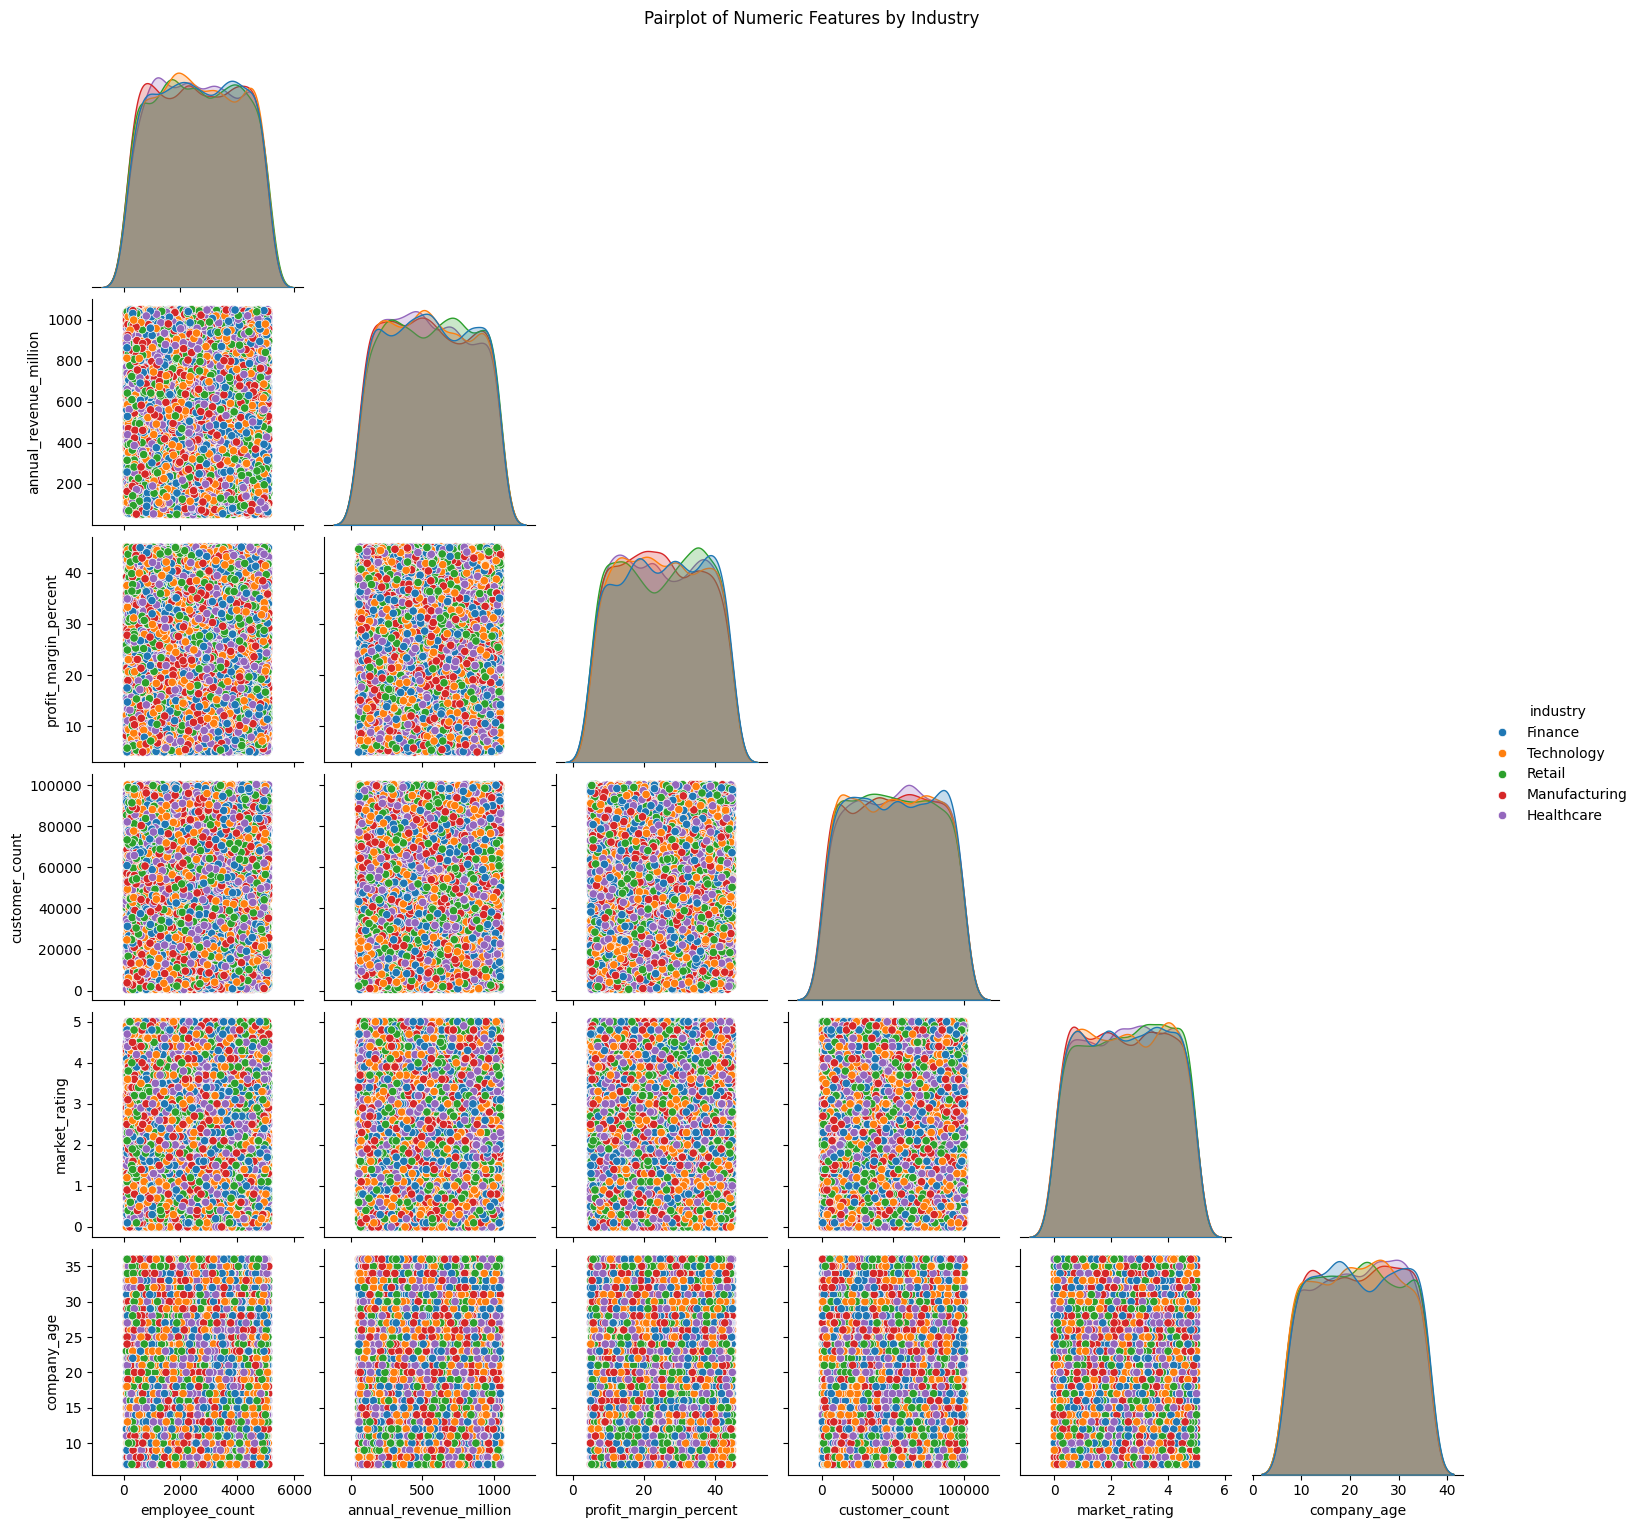

Group mean summaries by category:

Industry:


,employee_count,annual_revenue_million,profit_margin_percent,customer_count,market_rating,company_age
industry,,,,,,
Finance,2621.878333,552.823690,25.303310,50665.919000,2.512100,21.752333
Healthcare,2610.893667,543.457277,24.878077,51025.384333,2.515967,21.664333
Manufacturing,2582.221000,545.575197,24.762147,50220.057333,2.491100,21.697333
Retail,2608.425000,556.609343,25.085197,49979.257333,2.554533,21.537333
Technology,2610.892333,550.198027,25.031367,50355.641333,2.495200,21.478667



Country:


,employee_count,annual_revenue_million,profit_margin_percent,customer_count,market_rating,company_age
country,,,,,,
Canada,2558.102667,548.375403,25.000403,51453.220533,2.511147,21.6104
Germany,2634.276533,545.775243,25.018747,50197.027200,2.521973,21.6680
India,2600.321333,551.872211,25.077557,49993.631200,2.503733,21.6728
USA,2634.747733,552.907971,24.951371,50153.128533,2.518267,21.5528



Region:


,employee_count,annual_revenue_million,profit_margin_percent,customer_count,market_rating,company_age
region,,,,,,
Asia,2600.321333,551.872211,25.077557,49993.631200,2.503733,21.6728
Europe,2634.276533,545.775243,25.018747,50197.027200,2.521973,21.6680
North America,2596.425200,550.641687,24.975887,50803.174533,2.514707,21.5816


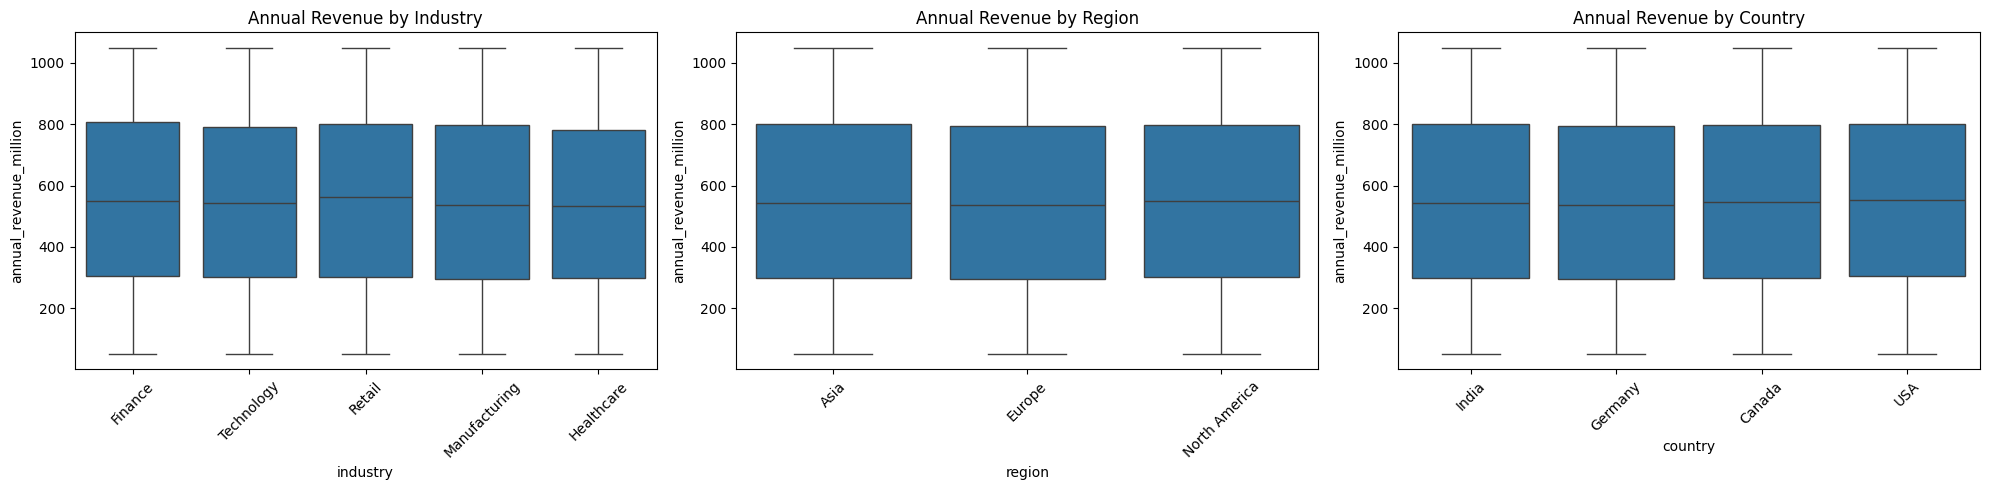

In [71]:
# Step 9 : Multivariate Analysis
# Derive company age and analyze numeric relationships with heatmaps and pairplots
current_year = pd.Timestamp.now().year
if 'company_age' not in df.columns:
    df['company_age'] = current_year - df['founded_year']

numeric_cols = [
    'employee_count',
    'annual_revenue_million',
    'profit_margin_percent',
    'customer_count',
    'market_rating',
    'company_age'
]

print('Numeric columns used for multivariate analysis:')
print(numeric_cols)

corr = df[numeric_cols].corr()
print('\nCorrelation matrix:')
print(corr)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap for Numeric Features')
plt.show()

sns.pairplot(df[numeric_cols], corner=True, kind='reg')
plt.suptitle('Pairplot for Numeric Features', y=1.02)
plt.show()

sns.pairplot(df[numeric_cols + ['industry']], hue='industry', corner=True)
plt.suptitle('Pairplot of Numeric Features by Industry', y=1.02)
plt.show()

print('Group mean summaries by category:')
print('\nIndustry:')
display(df.groupby('industry')[numeric_cols].mean())
print('\nCountry:')
display(df.groupby('country')[numeric_cols].mean())
print('\nRegion:')
display(df.groupby('region')[numeric_cols].mean())

fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=False)
sns.boxplot(x='industry', y='annual_revenue_million', data=df, ax=axes[0])
axes[0].set_title('Annual Revenue by Industry')
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(x='region', y='annual_revenue_million', data=df, ax=axes[1])
axes[1].set_title('Annual Revenue by Region')
axes[1].tick_params(axis='x', rotation=45)

sns.boxplot(x='country', y='annual_revenue_million', data=df, ax=axes[2])
axes[2].set_title('Annual Revenue by Country')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [82]:
df.head()

,id,company_name,industry,country,employee_count,annual_revenue_million,profit_margin_percent,founded_year,customer_count,market_rating,created_date,region
0,1,FinTrust_1,Finance,India,535,539.38,40.42,2010,81191,0.7,2025-10-13,Asia
1,2,TechNova_2,Technology,Germany,3806,852.42,39.55,2010,92162,3.4,2025-01-12,Europe
2,3,RetailHub_3,Retail,Canada,2779,257.11,23.68,1996,27532,2.9,2025-04-05,North America
3,4,BuildWorks_4,Manufacturing,USA,835,309.14,31.31,1993,90815,0.9,2026-01-02,North America
4,5,MediCorp_5,Healthcare,India,4490,988.68,43.65,1996,850,0.5,2025-06-29,Asia


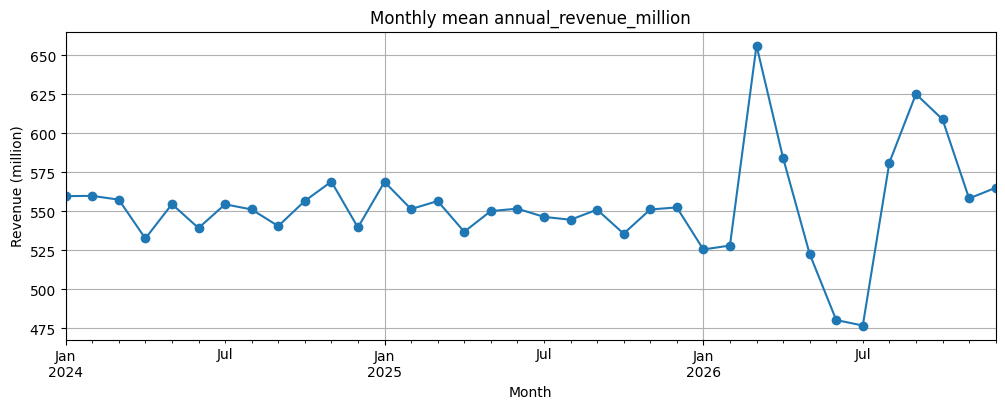

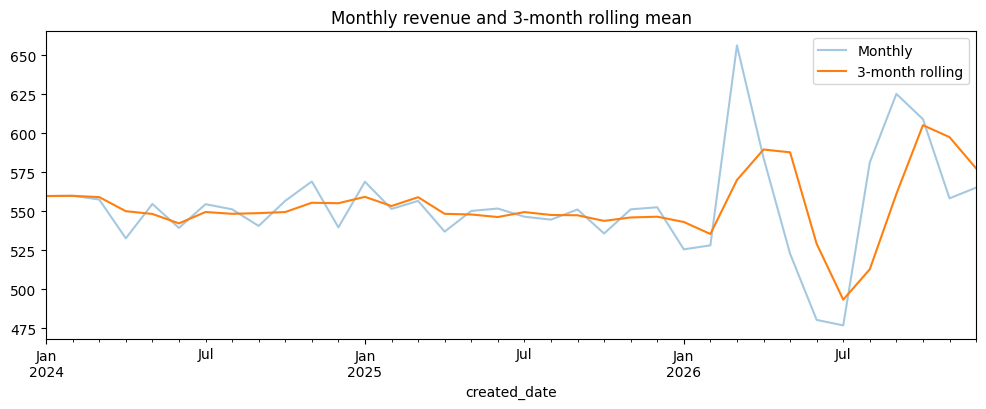

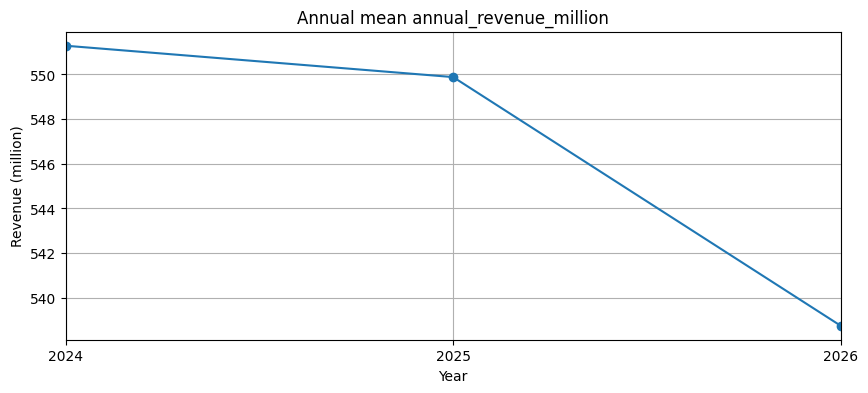

Approximate CAGR over 2 years: -1.14%


<Figure size 1200x500 with 0 Axes>

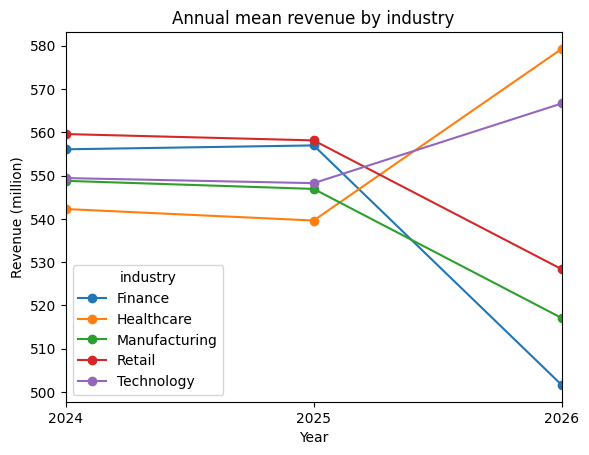

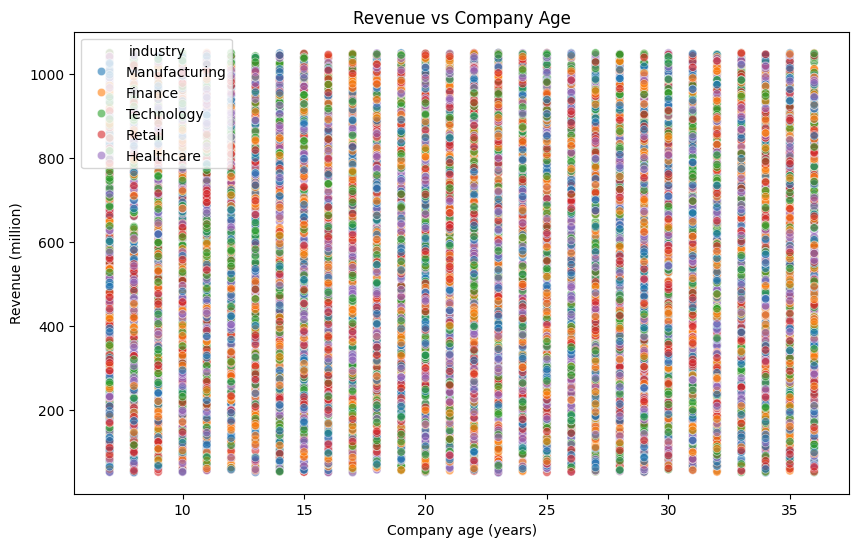

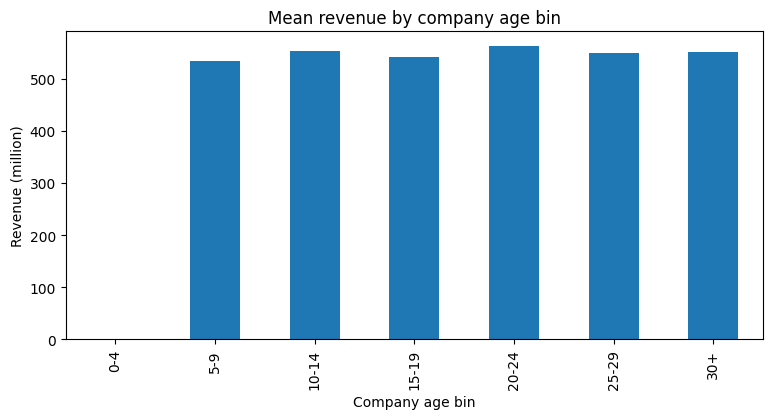


Mean revenue by age bin:
age_bin
0-4        0.000000
5-9      534.035199
10-14    554.117078
15-19    540.992432
20-24    562.508830
25-29    548.987294
30+      550.862087
Name: annual_revenue_million, dtype: float64

Trend analysis summary:
- Monthly and annual plots show the overall revenue level and short-term noise; apply rolling mean to highlight trend.
- If CAGR is small or near-zero, revenue is stable over the observed period.
- Industry-specific annual trends reveal whether a particular sector is growing or declining relative to others.
- Company age analysis shows whether older or younger firms have systematically different revenues (see age-bin means).


In [72]:
# Step 10 : Trend analysis using `created_date` and `company_age`
# Ensure created_date is datetime and data is sorted
df['created_date'] = pd.to_datetime(df['created_date'])
df = df.sort_values('created_date')

# Monthly mean revenue (time series)
monthly = df.set_index('created_date')['annual_revenue_million'].resample('M').mean()
plt.figure(figsize=(12,4))
monthly.plot(marker='o')
plt.title('Monthly mean annual_revenue_million')
plt.ylabel('Revenue (million)')
plt.xlabel('Month')
plt.grid(True)
plt.show()

# Rolling average to smooth short-term noise
monthly_rolling = monthly.rolling(window=3, min_periods=1).mean()
plt.figure(figsize=(12,4))
monthly.plot(alpha=0.4, label='Monthly')
monthly_rolling.plot(label='3‑month rolling')
plt.legend()
plt.title('Monthly revenue and 3-month rolling mean')
plt.show()

# Annual trend
annual = df.set_index('created_date')['annual_revenue_million'].resample('Y').mean()
plt.figure(figsize=(10,4))
annual.plot(marker='o')
plt.title('Annual mean annual_revenue_million')
plt.ylabel('Revenue (million)')
plt.xlabel('Year')
plt.grid(True)
plt.show()

# Approximate CAGR for available years (if possible)
if len(annual) >= 2:
    start_val = annual.iloc[0]
    end_val = annual.iloc[-1]
    n_years = annual.index[-1].year - annual.index[0].year
    if start_val > 0 and n_years > 0:
        cagr = (end_val / start_val) ** (1 / n_years) - 1
        print(f'Approximate CAGR over {n_years} years: {cagr:.2%}')

# Annual revenue by industry (compare trends)
pivot_ind = df.groupby([pd.Grouper(key='created_date', freq='Y'), 'industry'])['annual_revenue_million'].mean().unstack()
plt.figure(figsize=(12,5))
pivot_ind.plot(marker='o')
plt.title('Annual mean revenue by industry')
plt.ylabel('Revenue (million)')
plt.xlabel('Year')
plt.legend(title='industry')
plt.show()

# Relationship: company_age vs revenue
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='company_age', y='annual_revenue_million', hue='industry', alpha=0.6)
plt.title('Revenue vs Company Age')
plt.ylabel('Revenue (million)')
plt.xlabel('Company age (years)')
plt.show()

# Bucket company_age and summarize
bins = [0,5,10,15,20,25,30,100]
labels = ['0-4','5-9','10-14','15-19','20-24','25-29','30+']
df['age_bin'] = pd.cut(df['company_age'], bins=bins, labels=labels, right=False)
age_summary = df.groupby('age_bin')['annual_revenue_million'].mean()
plt.figure(figsize=(9,4))
age_summary.plot(kind='bar')
plt.title('Mean revenue by company age bin')
plt.ylabel('Revenue (million)')
plt.xlabel('Company age bin')
plt.show()

print('\nMean revenue by age bin:')
print(age_summary.fillna(0))

# Short textual interpretation for the notebook
print('\nTrend analysis summary:')
print('- Monthly and annual plots show the overall revenue level and short-term noise; apply rolling mean to highlight trend.')
print("- If CAGR is small or near-zero, revenue is stable over the observed period.")
print('- Industry-specific annual trends reveal whether a particular sector is growing or declining relative to others.')
print('- Company age analysis shows whether older or younger firms have systematically different revenues (see age-bin means).')

Top companies by total revenue: ['FinTrust_861', 'BuildWorks_6294', 'FinTrust_11911', 'TechNova_8217', 'RetailHub_12908']


<Figure size 1200x500 with 0 Axes>

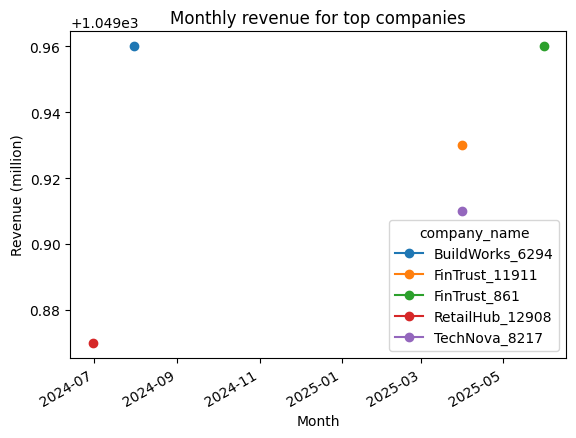

Spike month: 2025-01-31 00:00:00
Top contributors in spike month:
 company_name
MediCorp_445      1049.57
RetailHub_6253    1047.51
MediCorp_9730     1045.66
TechNova_4477     1044.90
TechNova_9407     1043.52
Name: annual_revenue_million, dtype: float64
Kruskal-Wallis across industries: stat=4.092, p=0.3936
 -> Fail to reject: no evidence of median differences across industries
Kruskal-Wallis across age bins: stat=12.142, p=0.0329
 -> Reject null: at least one age-bin median differs

Summary results: {'top_companies': ['FinTrust_861', 'BuildWorks_6294', 'FinTrust_11911', 'TechNova_8217', 'RetailHub_12908'], 'spike_month': '2025-01-31', 'spike_contributors_top5': {'MediCorp_445': 1049.57, 'RetailHub_6253': 1047.51, 'MediCorp_9730': 1045.66, 'TechNova_4477': 1044.9, 'TechNova_9407': 1043.52}, 'kw_industry_p': 0.39364830139754325, 'kw_age_p': 0.03289601513044268}


In [73]:
# Step 11 : Per-company time-series checks and statistical tests
import numpy as np
from scipy.stats import f_oneway, kruskal

# Ensure dates and company_age present
df['created_date'] = pd.to_datetime(df['created_date'])
if 'company_age' not in df.columns:
    df['company_age'] = pd.Timestamp.now().year - df['founded_year']

# Top companies by total revenue
company_tot = df.groupby('company_name')['annual_revenue_million'].sum().sort_values(ascending=False)
top_companies = company_tot.head(5).index.tolist()
print('Top companies by total revenue:', top_companies)

# Monthly revenue for top companies
monthly_comp = df[df['company_name'].isin(top_companies)].set_index('created_date').groupby('company_name')['annual_revenue_million'].resample('M').mean().unstack(0)
plt.figure(figsize=(12,5))
monthly_comp.plot(marker='o')
plt.title('Monthly revenue for top companies')
plt.ylabel('Revenue (million)')
plt.xlabel('Month')
plt.legend(title='company_name')
plt.show()

# Check if 2026 spike is driven by a few companies
monthly_total = df.set_index('created_date').groupby(pd.Grouper(freq='M'))['annual_revenue_million'].sum()
spike_month = monthly_total.idxmax()
print('Spike month:', spike_month)
contrib = df[df['created_date'].dt.to_period('M') == spike_month.to_period('M')].groupby('company_name')['annual_revenue_million'].sum().sort_values(ascending=False)
print('Top contributors in spike month:\n', contrib.head())

# Statistical tests: industry and age_bin
if 'age_bin' not in df.columns:
    bins = [0,5,10,15,20,25,30,100]
    labels = ['0-4','5-9','10-14','15-19','20-24','25-29','30+']
    df['age_bin'] = pd.cut(df['company_age'], bins=bins, labels=labels, right=False)

# Prepare groups
industry_groups = [group['annual_revenue_million'].values for name, group in df.groupby('industry')]
age_groups = [group['annual_revenue_million'].values for name, group in df.groupby('age_bin') if len(group)>0]

# Use Kruskal-Wallis (non-parametric) as safer default
if len(industry_groups) >= 2:
    stat_ind, p_ind = kruskal(*industry_groups)
    print(f'Kruskal-Wallis across industries: stat={stat_ind:.3f}, p={p_ind:.4f}')
    if p_ind < 0.05:
        print(' -> Reject null: at least one industry median differs')
    else:
        print(' -> Fail to reject: no evidence of median differences across industries')

if len(age_groups) >= 2:
    stat_age, p_age = kruskal(*age_groups)
    print(f'Kruskal-Wallis across age bins: stat={stat_age:.3f}, p={p_age:.4f}')
    if p_age < 0.05:
        print(' -> Reject null: at least one age-bin median differs')
    else:
        print(' -> Fail to reject: no evidence of median differences across age bins')

# Save results summary to notebook outputs
results = {
    'top_companies': top_companies,
    'spike_month': str(spike_month.date()) if spike_month is not None else None,
    'spike_contributors_top5': contrib.head().to_dict(),
    'kw_industry_p': float(p_ind) if 'p_ind' in locals() else None,
    'kw_age_p': float(p_age) if 'p_age' in locals() else None
}
print('\nSummary results:', results)

C:\Users\91702\AppData\Local\Temp\ipykernel_26996\1539442818.py:11: UserWarning: Parsing dates in DD/MM/YYYY format when dayfirst=False (the default) was specified. This may lead to inconsistently parsed dates! Specify a format to ensure consistent parsing.
  df['created_date'] = pd.to_datetime(df['created_date'], errors='coerce')


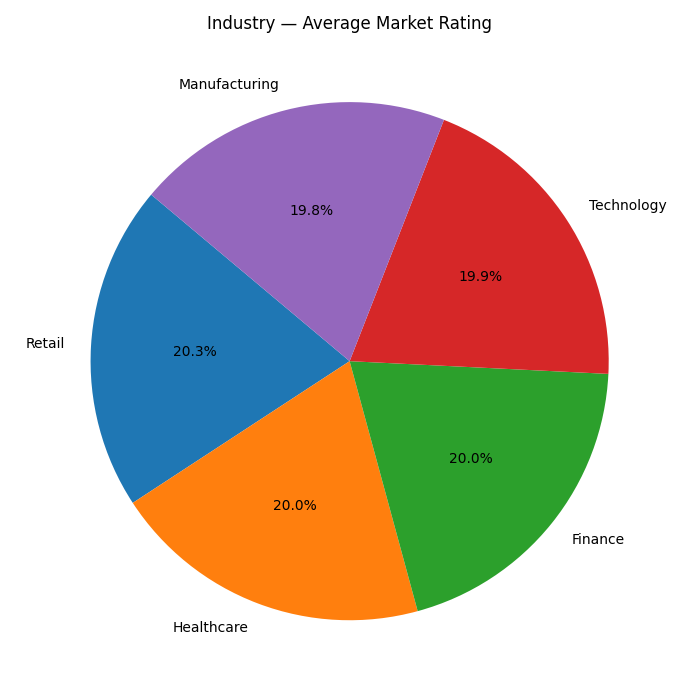

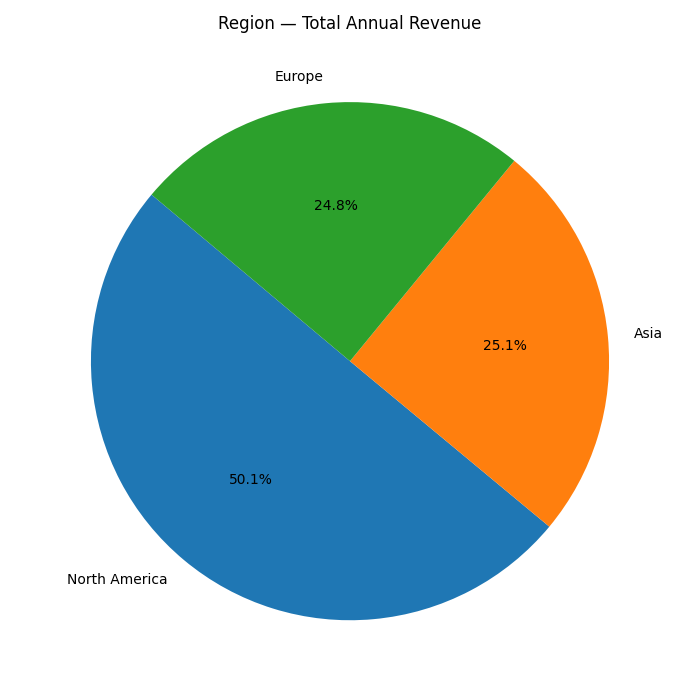

In [77]:
# Step 12 : Pie charts (industry avg rating, region annual revenue, company customer_count)
from pathlib import Path
import matplotlib.pyplot as plt
from IPython.display import Image, display
plots_dir = Path('plots')
plots_dir.mkdir(exist_ok=True)
# reload data to ensure fresh state
import pandas as pd
df = pd.read_csv('INDUSTRY.csv')
if 'created_date' in df.columns:
    df['created_date'] = pd.to_datetime(df['created_date'], errors='coerce')

# 1) Industry - average market rating (pie)
if 'industry' in df.columns and 'market_rating' in df.columns:
    ind_rating = df.groupby('industry')['market_rating'].mean().dropna().sort_values(ascending=False)
    if len(ind_rating) > 10:
        top = ind_rating.iloc[:10].copy()
        top['Other'] = ind_rating.iloc[10:].sum()
        pie_series = top
    else:
        pie_series = ind_rating
    plt.figure(figsize=(7,7))
    pie_series.plot.pie(autopct='%1.1f%%', startangle=140)
    plt.ylabel('')
    plt.title('Industry — Average Market Rating')
    plt.tight_layout()
    fn = plots_dir / 'pie_industry_avg_rating_notebook.png'
    plt.savefig(fn)
    plt.close()
    display(Image(str(fn)))

# 2) Region-wise annual revenue (pie)
if 'region' in df.columns and 'annual_revenue_million' in df.columns:
    region_rev = df.groupby('region')['annual_revenue_million'].sum().dropna().sort_values(ascending=False)
    total = region_rev.sum() if not region_rev.empty else 0
    if total>0:
        large = region_rev[region_rev / total >= 0.05]
        small = region_rev[region_rev / total < 0.05]
        if not small.empty:
            large['Other'] = small.sum()
        pie_series = large
        plt.figure(figsize=(7,7))
        pie_series.plot.pie(autopct='%1.1f%%', startangle=140)
        plt.ylabel('')
        plt.title('Region — Total Annual Revenue')
        plt.tight_layout()
        fn = plots_dir / 'pie_region_annual_revenue_notebook.png'
        plt.savefig(fn)
        plt.close()
        display(Image(str(fn)))





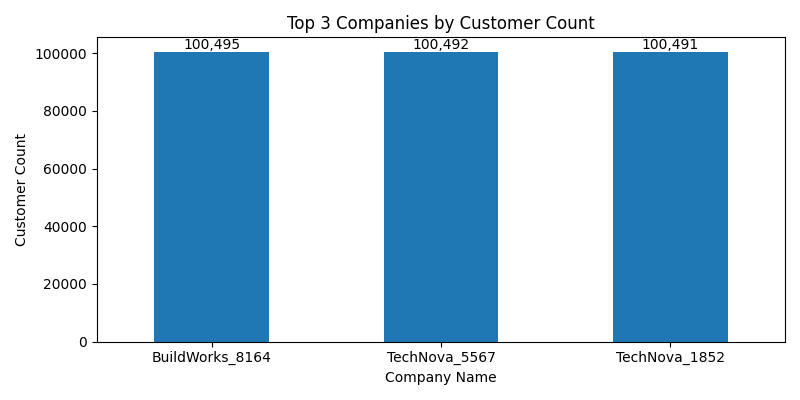

In [75]:
# Step 13: Top-3 companies by customer count (bar chart with labels)
from pathlib import Path
import matplotlib.pyplot as plt
from IPython.display import Image, display
plots_dir = Path('plots')
plots_dir.mkdir(exist_ok=True)
import pandas as pd

df = pd.read_csv('INDUSTRY.csv')
if 'company_name' in df.columns and 'customer_count' in df.columns:
    comp_cust = df.groupby('company_name')['customer_count'].sum().dropna().sort_values(ascending=False)
    top3 = comp_cust.head(3)
    plt.figure(figsize=(8,4))
    ax = top3.plot(kind='bar', color='tab:blue')
    ax.set_title('Top 3 Companies by Customer Count')
    ax.set_ylabel('Customer Count')
    ax.set_xlabel('Company Name')
    ax.set_xticklabels([str(x) for x in top3.index], rotation=0, ha='center')
    # Annotate values above bars
    for p in ax.patches:
        ax.annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width()/2, p.get_height()), ha='center', va='bottom')
    fn = plots_dir / 'top3_company_customer_count_notebook.png'
    plt.tight_layout()
    plt.savefig(fn)
    plt.close()
    display(Image(str(fn)))
else:
    print('Required columns `company_name` and/or `customer_count` are missing in INDUSTRY.csv')
